### Dados de 2022

### 15-50kev

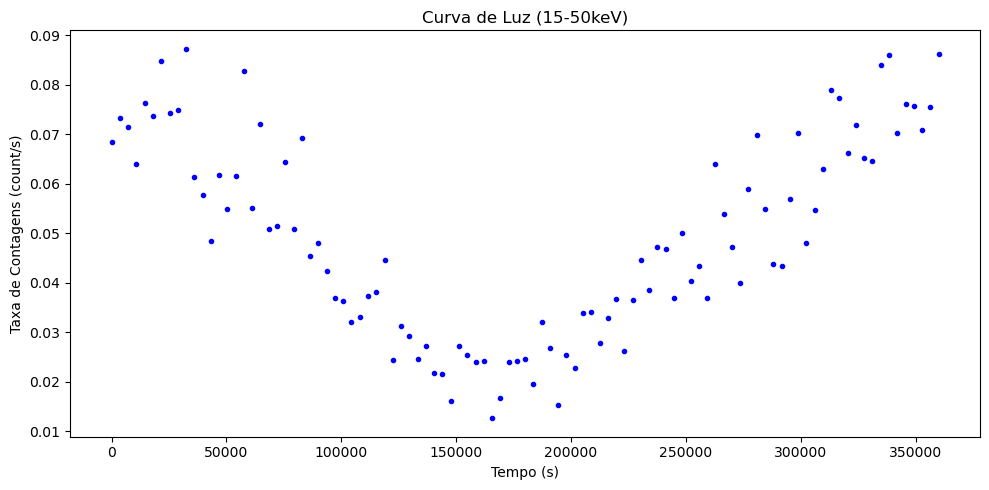

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/15-50kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (15-50keV)')


plt.tight_layout()
plt.show()

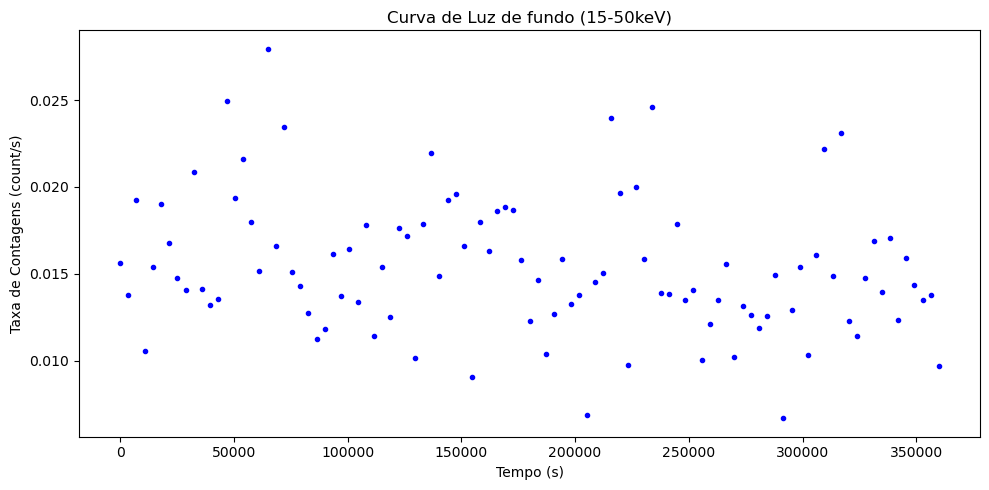

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/15-50kev/nu30701024002A01_bk.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz de fundo (15-50keV)')


plt.tight_layout()
plt.show()

### Fator de escala e Correção de fundo

Region file format: 
DS9 version 4.1

global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
physical

circle(496.83301,419.58485,38.948665) # text={bkgB01}

circle(499.61088,499.4459,18.984525) # text={srcB01}

circle (x,y,radius)

a = Asrc² / Abkg² = Rsrc² / Rbkg²

data = src - (a * bkg)

propagação de erro:

data = src - a*bkg

sigma_data = sqrt(sigma_src² + a² * sigma_bkg²)

In [ ]:
import numpy as np
from astropy.table import Table

src = Table.read('data/Dados 2022/15-50kev/nu30701024002A01_sr.lc', hdu=1)
bkg = Table.read('data/Dados 2022/15-50kev/nu30701024002A01_bk.lc', hdu=1)

# Fator de escala
a = 38.948665**2 / 18.984525**2
print(a)

# subtração do fundo corrigido 
# propagação de erro
rate_sub = src['RATE'] - (a * bkg['RATE'])
err_sub = np.sqrt(src['ERROR'] ** 2 + (a * bkg['ERROR']) ** 2)

lc_clean = src.copy()
lc_clean['RATE'] = rate_sub
lc_clean['ERROR'] = err_sub

lc_clean.write('lc_fonte_sub_15-50kev.lc', format='fits', overwrite=True)  #Salva o arquivo corrigido

4.209065479969902


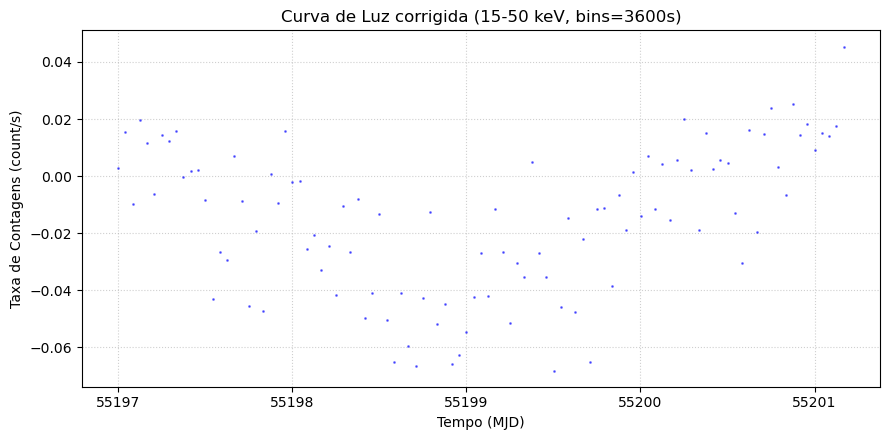

In [24]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/Dados 2022/15-50kev/lc_fonte_sub_15-50kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz corrigida (15-50 keV, bins=3600s)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

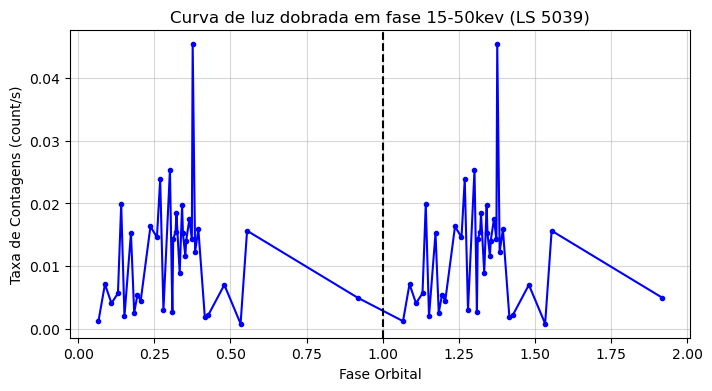

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

df = Table.read('data/Dados 2022/15-50kev/lc_fonte_sub_15-50kev.lc', hdu=1).to_pandas()
df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)


T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase 15-50kev (LS 5039)')
plt.grid(True, alpha=0.5)
plt.show()

#### 3-10kev

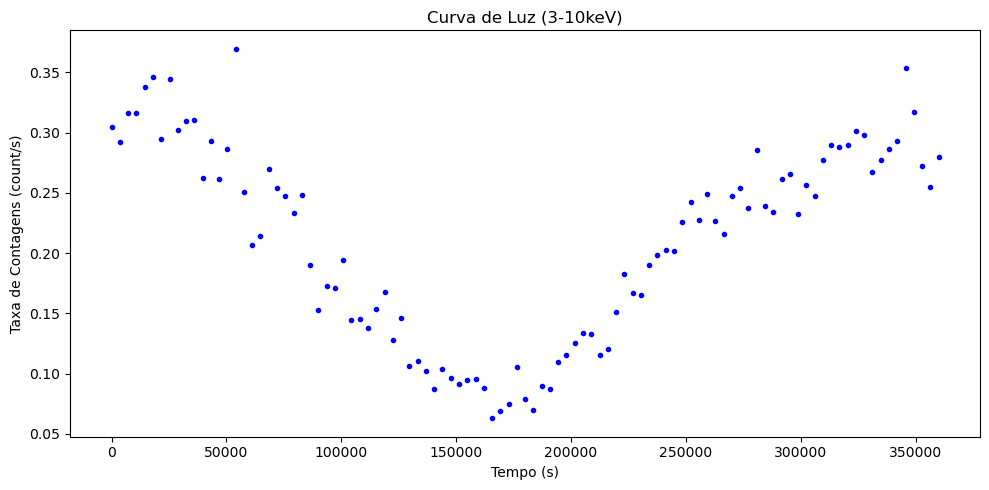

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/3-10kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV)')


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from astropy.table import Table

src = Table.read('data/ bins 60s/30-70kev/nu30201034002A01_sr.lc', hdu=1)
bkg = Table.read('data/ bins 60s/30-70kev/nu30201034002A01_bk.lc', hdu=1)

# Fator de escala
a = 0.1357101996

# subtração do fundo corrigido 
# propagação de erro
rate_sub = src['RATE'] - (a * bkg['RATE'])
err_sub = np.sqrt(src['ERROR'] ** 2 + (a * bkg['ERROR']) ** 2)

lc_clean = src.copy()
lc_clean['RATE'] = rate_sub
lc_clean['ERROR'] = err_sub

lc_clean.write('lc_fonte_sub_30-70kev.lc', format='fits', overwrite=True)

In [6]:
from astropy.io import fits

hdr = fits.getheader('data/Dados 2022/3-10kev/nu30701024002A01_sr.lc', hdu=1)

chaves = [
    'OBJECT',
    'TELESCOP',
    'INSTRUME',
    'OBS_ID',
    'DATE-OBS',
    'DATE-END',
    'MJDREFI',
    'MJDREFF',
    'TSTART',
    'TSTOP',
    'ONTIME',
]

for chave in chaves:
    if chave in hdr:
        print(f'{chave:10s} = {hdr[chave]} \t/ {hdr.comments[chave]}')

OBJECT     = LS_5039 	/ Name of observed object
TELESCOP   = NuSTAR 	/ Telescope (mission) name
INSTRUME   = FPMA 	/ Instrument name
OBS_ID     = 30701024002 	/ Observation ID
DATE-OBS   = 2022-04-09T22:48:12.6041 	/ Start date of observations
DATE-END   = 2022-04-14T03:29:03.0345 	/ End date of observations
MJDREFI    = 55197 	/ MJD reference day
MJDREFF    = 0.00076601852 	/ MJD reference (fraction of day)
TSTART     = 387240426.4200499 	/ time start
TSTOP      = 387602876.8504873 	/ time stop
ONTIME     = 194468.0829269886 	/ On-source time


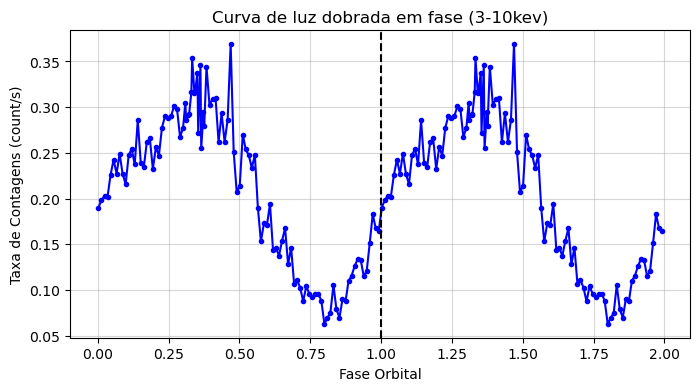

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

caminho = 'data/Dados 2022/3-10kev/nu30701024002A01_sr.lc'

tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (3-10kev)')
plt.grid(True, alpha=0.5)
plt.show()

### Correção de fundo

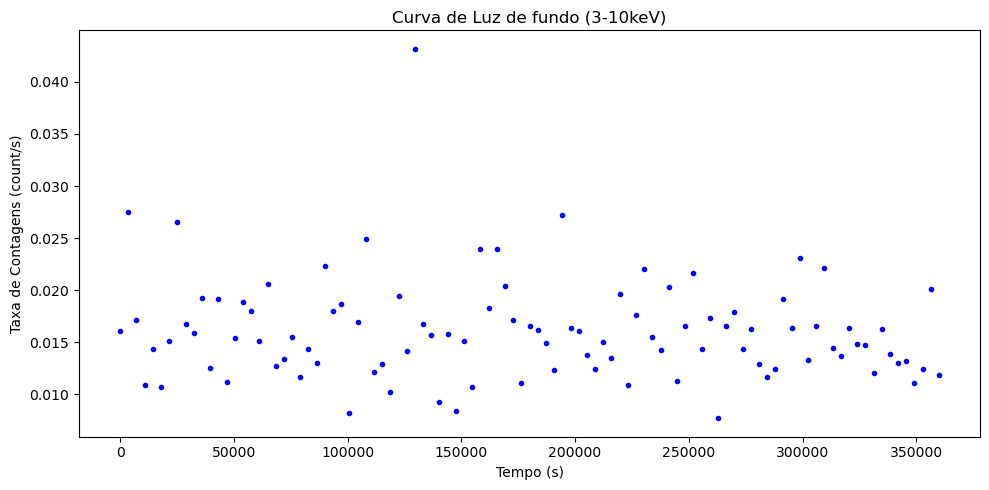

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/3-10kev/nu30701024002A01_bk.lc')
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz de fundo (3-10keV)')


plt.tight_layout()
plt.show()

### 10-30kev

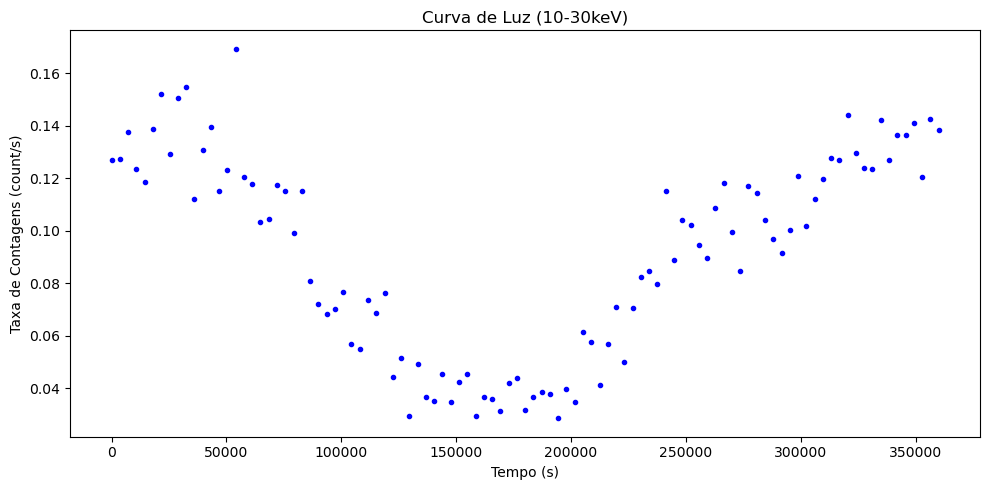

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/10-30kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30keV)')


plt.tight_layout()
plt.show()

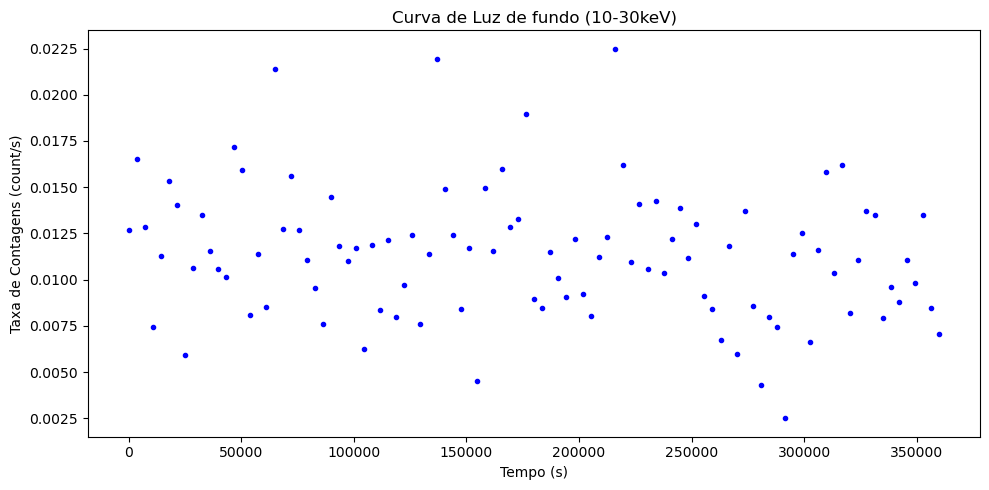

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/10-30kev/nu30701024002A01_bk.lc')
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz de fundo (10-30keV)')


plt.tight_layout()
plt.show()

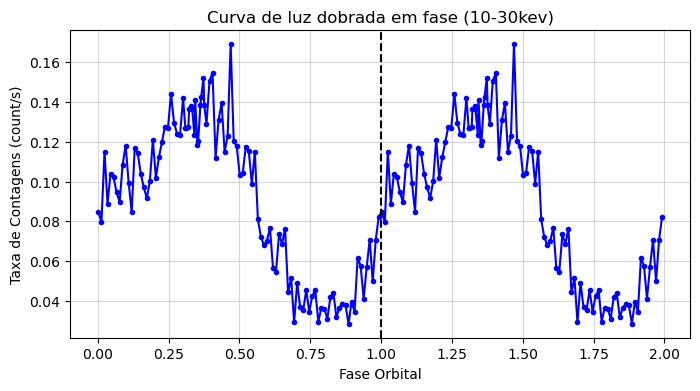

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

caminho = 'data/Dados 2022/10-30kev/nu30701024002A01_sr.lc'

tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (10-30kev)')
plt.grid(True, alpha=0.5)
plt.show()

### 30-70kev

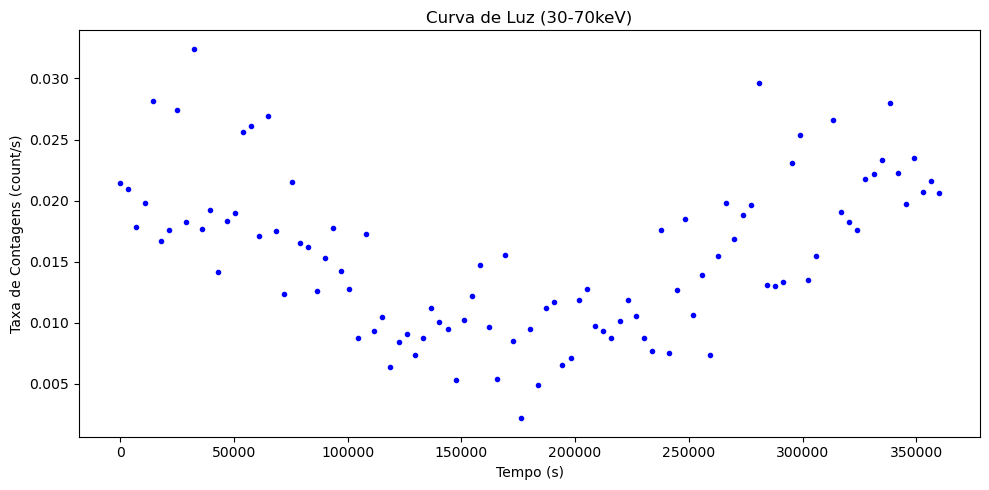

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/30-70kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70keV)')


plt.tight_layout()
plt.show()

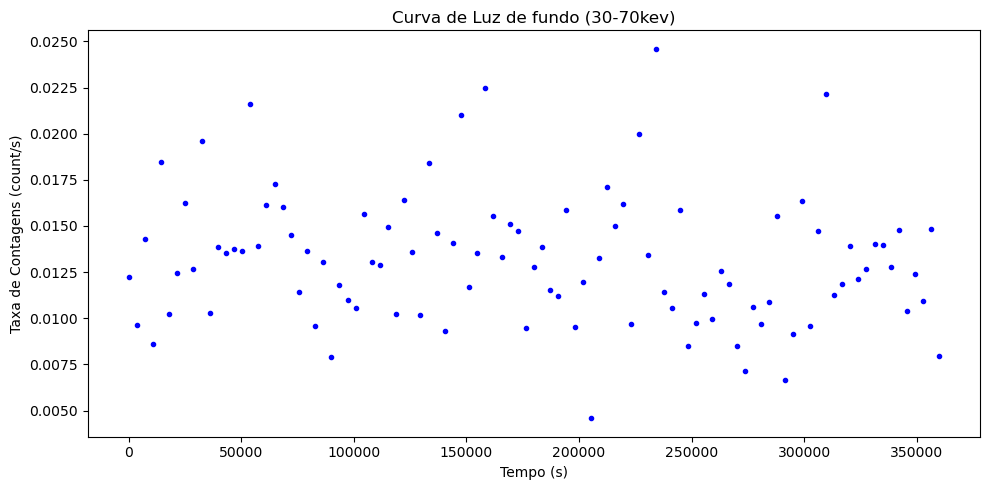

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/30-70kev/nu30701024002A01_bk.lc')
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz de fundo (30-70kev)')


plt.tight_layout()
plt.show()

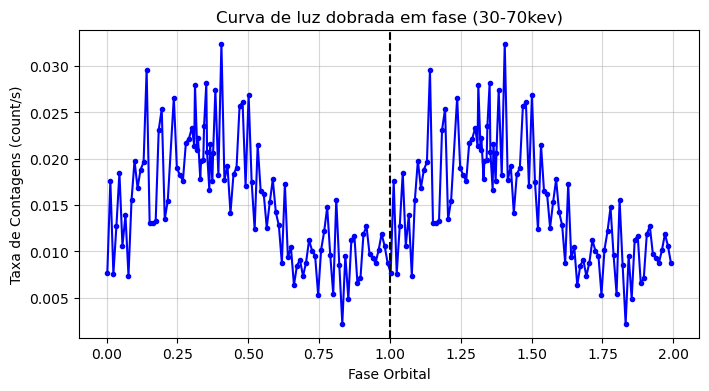

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

caminho = 'data/Dados 2022/30-70kev/nu30701024002A01_sr.lc'

tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (30-70kev)')
plt.grid(True, alpha=0.5)
plt.show()